<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v2.0</br>
📅 Last Updated: 2026-03-12</br>
</div>

</br>

In [53]:
# TODO 0: 실습을 위해 아래 패키지를 import 해주세요.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine

</br>

# 학습 내용
>이번 장에서는 <strong>데이터 탐색(Exploratory Data Analysis)</strong>에 대해 학습합니다.</br></br>
>데이터의 구조, 분포, 상관관계를 파악하고 시각화하는 방법을 학습해봅시다.

</br>

# 데이터 탐색 (EDA)
> 데이터 탐색은 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">모델링 전에 데이터의 특성과 패턴을 이해</mark>하는 과정입니다.
> 좋은 EDA는 전처리 전략과 모델 선택의 방향을 결정합니다.

>머신러닝 프로젝트에서 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">EDA(탐색적 데이터 분석)</mark>는 가장 먼저 수행해야 하는 필수 단계입니다.</br></br>
>데이터를 이해하지 않고 바로 모델을 만들면 잘못된 피처 선택, 스케일 문제 미인지, 데이터 누수(Data Leakage) 미탐지, 분포 왜곡, 클래스 불균형 등 다양한 문제가 발생합니다.</br></br>
>EDA의 목적은 단순한 확인이 아니라, <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">어떤 전처리가 필요한지, 어떤 모델이 적합한지, 어떤 피처가 중요한지</mark>를 데이터에서 직접 읽어내는 것입니다.</br></br>
> 좋은 EDA는 이후 모든 단계의 방향을 결정하는 나침반 역할을 합니다.</br>

</br>

## 기본 정보 확인

In [54]:
# TODO 1: wine_dataset에 wine 데이터를 로드해봅시다.

wine_dataset = load_wine()

In [55]:
# TODO 2: wine_dataframe에 wine_dataset를 데이터프레임으로 변경해봅시다.

wine_dataframe = pd.DataFrame(wine_dataset.data, columns=wine_dataset.feature_names)

In [56]:
# TODO 3: wine_dataframe에 'quality' 컬럼을 추가해봅시다.

wine_dataframe["quality"] = wine_dataset.target

In [57]:
# TODO 4: 데이터의 크기와 처음 3행을 출력해봅시다.

print(wine_dataframe.shape)
print(wine_dataframe.head(3))

(178, 14)
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   

   od280/od315_of_diluted_wines  proline  quality  
0                          3.92   1065.0        0  
1                          3.40   1050.0        0  
2                          3.17   1185.0        0  


In [58]:
# TODO 5: 수치형 컬럼의 기술통계량을 확인해봅시다.

print(wine_dataframe.describe())

          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453         0.572359   
min         0.9

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">메서드</th>
      <th style="text-align:center">설명</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center"><code>df.shape</code></td><td style="text-align:center">(행 수, 열 수)</td></tr>
    <tr><td style="text-align:center"><code>df.info()</code></td><td style="text-align:center">열별 타입, 결측치 수</td></tr>
    <tr><td style="text-align:center"><code>df.describe()</code></td><td style="text-align:center">수치형 통계 요약 (평균, 표준편차, 사분위수)</td></tr>
    <tr><td style="text-align:center"><code>df.head(n)</code></td><td style="text-align:center">처음 n행 미리보기</td></tr>
  </tbody>
</table>

</br>

## 데이터 심층 탐색
> 기본 통계 외에 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">클래스별 특성, 필터링, 집계</mark> 등 다양한 pandas 함수를 활용하여 데이터를 깊이 파악합니다.

In [59]:
# TODO 6: quality 컬럼의 고유 클래스 수와 클래스별 샘플 수를 확인해봅시다.

print(f"클래스 수: {wine_dataframe['quality'].nunique()}")
print(wine_dataframe['quality'].value_counts().sort_index())

클래스 수: 3
quality
0    59
1    71
2    48
Name: count, dtype: int64


In [60]:
# TODO 7: 클래스별 alcohol 평균을 구하고, 평균이 가장 높은 클래스를 찾아봅시다.

# 클래스별 alcohol 평균
alcohol_by_class = wine_dataframe.groupby("quality")["alcohol"].mean()
print(alcohol_by_class)

# 평균이 가장 높은 클래스
top_class = alcohol_by_class.idxmax()
print(f"\nalcohol 평균이 가장 높은 클래스: {top_class}")

quality
0    13.744746
1    12.278732
2    13.153750
Name: alcohol, dtype: float64

alcohol 평균이 가장 높은 클래스: 0


In [61]:
# TODO 8: malic_acid의 평균과 표준편차를 구해봅시다.

malic_mean = wine_dataframe["malic_acid"].mean()
malic_std = wine_dataframe["malic_acid"].std()
print(f"malic_acid 평균: {malic_mean:.4f}")
print(f"malic_acid 표준편차: {malic_std:.4f}")

malic_acid 평균: 2.3363
malic_acid 표준편차: 1.1171


In [62]:
# TODO 9: color_intensity가 10 이상인 샘플의 비율(%)을 구해봅시다.

high_color_ratio = (wine_dataframe["color_intensity"] >= 10).mean() * 100
print(f"color_intensity >= 10 비율: {high_color_ratio:.2f}%")

color_intensity >= 10 비율: 3.93%


In [63]:
# TODO 10: wine_dataframe의 상관행렬을 구해봅시다. (수치형 데이터만 선택합니다.)

wine_correlation = wine_dataframe.corr(numeric_only=True)
print(wine_correlation)

                               alcohol  malic_acid       ash  \
alcohol                       1.000000    0.094397  0.211545   
malic_acid                    0.094397    1.000000  0.164045   
ash                           0.211545    0.164045  1.000000   
alcalinity_of_ash            -0.310235    0.288500  0.443367   
magnesium                     0.270798   -0.054575  0.286587   
total_phenols                 0.289101   -0.335167  0.128980   
flavanoids                    0.236815   -0.411007  0.115077   
nonflavanoid_phenols         -0.155929    0.292977  0.186230   
proanthocyanins               0.136698   -0.220746  0.009652   
color_intensity               0.546364    0.248985  0.258887   
hue                          -0.071747   -0.561296 -0.074667   
od280/od315_of_diluted_wines  0.072343   -0.368710  0.003911   
proline                       0.643720   -0.192011  0.223626   
quality                      -0.328222    0.437776 -0.049643   

                              alcalinit

In [64]:
# TODO 11: wine_correlation에서 "alcohol" 컬럼의 상관계수를 추출하고, 자기 자신(alcohol)을 제외해봅시다.

correlation_with_alcohol = wine_correlation["alcohol"].drop("alcohol")
print(correlation_with_alcohol)

malic_acid                      0.094397
ash                             0.211545
alcalinity_of_ash              -0.310235
magnesium                       0.270798
total_phenols                   0.289101
flavanoids                      0.236815
nonflavanoid_phenols           -0.155929
proanthocyanins                 0.136698
color_intensity                 0.546364
hue                            -0.071747
od280/od315_of_diluted_wines    0.072343
proline                         0.643720
quality                        -0.328222
Name: alcohol, dtype: float64


In [65]:
# TODO 12: 절대값 기준으로 alcohol과 상관관계가 가장 높은 특성을 찾아봅시다.

top_correlation_feature = correlation_with_alcohol.abs().idxmax()
top_correlation_value = correlation_with_alcohol[top_correlation_feature]
print(f"alcohol과 가장 상관 높은 특성: {top_correlation_feature} (r={top_correlation_value:.4f})")

alcohol과 가장 상관 높은 특성: proline (r=0.6437)


<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">메서드</th>
      <th style="text-align:center">설명</th>
      <th style="text-align:center">예시</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center"><code>nunique()</code></td><td style="text-align:center">고유값 개수</td><td style="text-align:center"><code>df["col"].nunique()</code></td></tr>
    <tr><td style="text-align:center"><code>value_counts()</code></td><td style="text-align:center">값별 빈도수</td><td style="text-align:center"><code>df["col"].value_counts()</code></td></tr>
    <tr><td style="text-align:center"><code>sort_index()</code></td><td style="text-align:center">인덱스 기준 정렬</td><td style="text-align:center"><code>series.sort_index()</code></td></tr>
    <tr><td style="text-align:center"><code>groupby()</code></td><td style="text-align:center">그룹별 집계</td><td style="text-align:center"><code>df.groupby("col")["target"].mean()</code></td></tr>
    <tr><td style="text-align:center"><code>idxmax()</code></td><td style="text-align:center">최대값의 인덱스</td><td style="text-align:center"><code>series.idxmax()</code></td></tr>
    <tr><td style="text-align:center"><code>std()</code></td><td style="text-align:center">표준편차</td><td style="text-align:center"><code>df["col"].std()</code></td></tr>
    <tr><td style="text-align:center"><code>corr()</code></td><td style="text-align:center">상관계수 행렬</td><td style="text-align:center"><code>df.corr()</code></td></tr>
  </tbody>
</table>

</br>

## 상관분석 (Correlation Analysis)
> 두 변수 간의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">선형 관계 강도</mark>를 -1 ~ 1 사이의 값으로 나타냅니다.

In [66]:
# TODO 13: wine_number_dataframe에 wine_dataframe에서 '수치형' 컬럼만 저장해봅시다.

wine_number_dataframe = wine_dataframe.select_dtypes(include="number")

In [67]:
# TODO 14: wine_number_dataframe의 상관행렬을 출력해봅시다.

correlation_matrix = wine_number_dataframe.corr()
print(correlation_matrix)

                               alcohol  malic_acid       ash  \
alcohol                       1.000000    0.094397  0.211545   
malic_acid                    0.094397    1.000000  0.164045   
ash                           0.211545    0.164045  1.000000   
alcalinity_of_ash            -0.310235    0.288500  0.443367   
magnesium                     0.270798   -0.054575  0.286587   
total_phenols                 0.289101   -0.335167  0.128980   
flavanoids                    0.236815   -0.411007  0.115077   
nonflavanoid_phenols         -0.155929    0.292977  0.186230   
proanthocyanins               0.136698   -0.220746  0.009652   
color_intensity               0.546364    0.248985  0.258887   
hue                          -0.071747   -0.561296 -0.074667   
od280/od315_of_diluted_wines  0.072343   -0.368710  0.003911   
proline                       0.643720   -0.192011  0.223626   
quality                      -0.328222    0.437776 -0.049643   

                              alcalinit

💡상관계수 해석
> 일반적으로 `|r| > 0.7`이면 강한 상관, `|r| < 0.3`이면 약한 상관으로 봅니다.

</br>

## 시각화 (Visualization)
> 데이터의 분포와 관계를 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">그래프로 직관적으로 파악</mark>합니다.

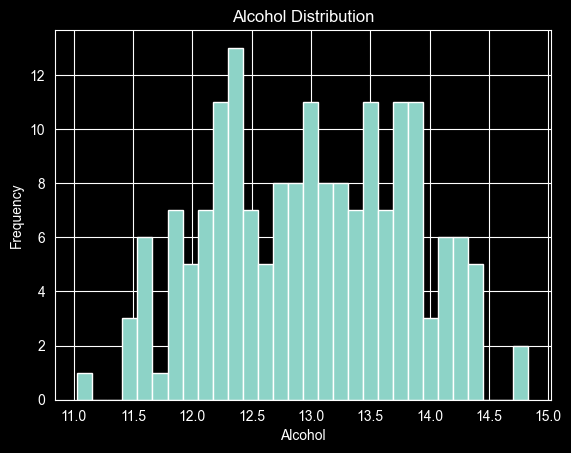

In [68]:
# TODO 15: wine_dataframe에서 'alcohol'의 히스토그램을 확인해봅시다.

wine_dataframe["alcohol"].hist(bins=30)
plt.title("Alcohol Distribution")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()

💡`bins` 속성이란?
> `bins`는 히스토그램에서 데이터를 나눌 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">구간(막대)의 개수</mark>를 지정합니다.</br>
> `bins` 값이 작으면 넓은 구간으로 대략적인 분포를, 크면 좁은 구간으로 세밀한 분포를 확인할 수 있습니다.</br></br>
> <table style="width:100%">
>   <thead>
>     <tr>
>       <th style="text-align:center">bins 값</th>
>       <th style="text-align:center">효과</th>
>       <th style="text-align:center">적합한 상황</th>
>     </tr>
>   </thead>
>   <tbody>
>     <tr><td style="text-align:center">작은 값 (5~10)</td><td style="text-align:center">넓은 구간, 부드러운 분포</td><td style="text-align:center">전체적인 경향 파악</td></tr>
>     <tr><td style="text-align:center">중간 값 (20~30)</td><td style="text-align:center">적당한 해상도</td><td style="text-align:center">일반적인 EDA</td></tr>
>     <tr><td style="text-align:center">큰 값 (50~100)</td><td style="text-align:center">좁은 구간, 세밀한 분포</td><td style="text-align:center">특정 구간 집중 분석</td></tr>
>   </tbody>
> </table></br>
> 지정하지 않으면 matplotlib은 기본값 `bins=10`을 사용합니다.

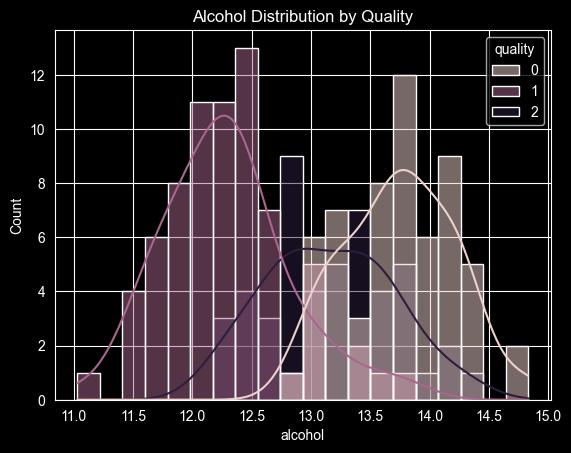

In [69]:
# TODO 16: 클래스별 alcohol 분포를 histplot으로 비교해봅시다. (hue="quality", kde=True)

sns.histplot(data=wine_dataframe, x="alcohol", hue="quality", bins=20, kde=True)
plt.title("Alcohol Distribution by Quality")
plt.show()

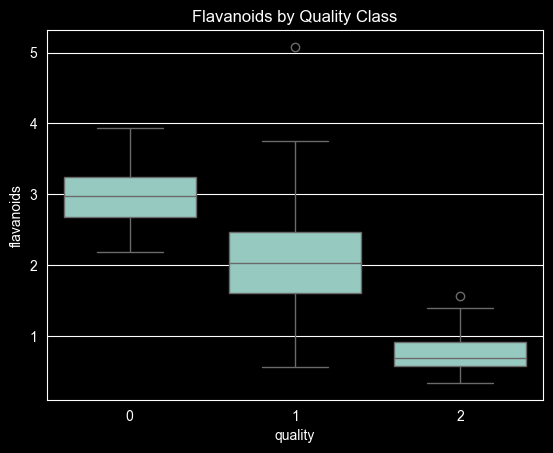

In [70]:
# TODO 17: 클래스별 flavanoids를 boxplot으로 비교해봅시다.

sns.boxplot(data=wine_dataframe, x="quality", y="flavanoids")
plt.title("Flavanoids by Quality Class")
plt.show()

💡시각화 방법 비교
> <table style="width:100%">
>   <thead>
>     <tr>
>       <th style="text-align:center">플롯</th>
>       <th style="text-align:center">용도</th>
>       <th style="text-align:center">핵심 파라미터</th>
>     </tr>
>   </thead>
>   <tbody>
>     <tr><td style="text-align:center"><code>histplot</code></td><td style="text-align:center">단일 변수의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">분포</mark> 확인</td><td style="text-align:center"><code>hue</code> (그룹별 비교), <code>kde</code> (밀도 곡선)</td></tr>
>     <tr><td style="text-align:center"><code>boxplot</code></td><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">중앙값, 사분위수, 이상치</mark> 한눈에 비교</td><td style="text-align:center"><code>x</code> (그룹), <code>y</code> (수치)</td></tr>
>     <tr><td style="text-align:center"><code>heatmap</code></td><td style="text-align:center">변수 간 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">상관관계</mark> 전체 조망</td><td style="text-align:center"><code>annot</code>, <code>cmap</code>, <code>fmt</code></td></tr>
>     <tr><td style="text-align:center"><code>scatterplot</code></td><td style="text-align:center">두 변수의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">관계</mark>와 클래스 분리</td><td style="text-align:center"><code>hue</code> (색상 구분)</td></tr>
>     <tr><td style="text-align:center"><code>pairplot</code></td><td style="text-align:center">여러 변수 쌍의 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">관계를 한 번에</mark> 탐색</td><td style="text-align:center"><code>hue</code>, <code>corner</code> (하삼각만)</td></tr>
>   </tbody>
> </table>

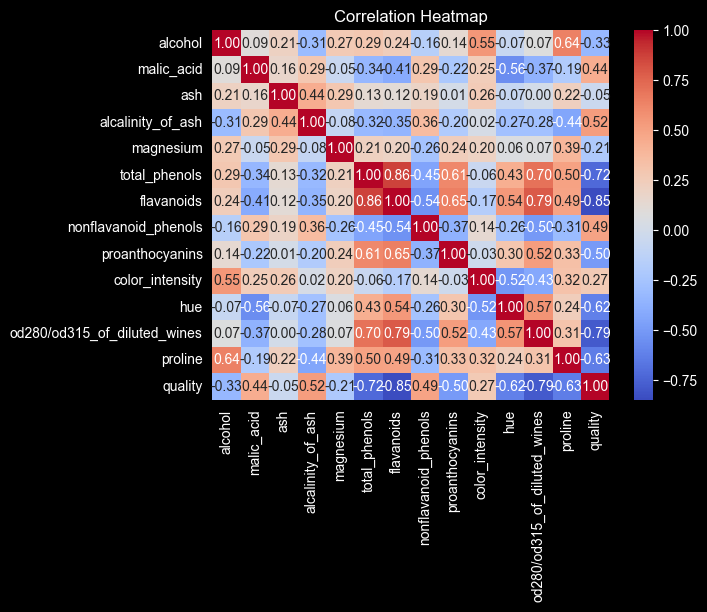

In [71]:
# TODO 18: wine_number_dataframe의 상관행렬을 시각화하여 확인해봅시다. (annot=True, cmap="coolwarm", fmt=".2f")

sns.heatmap(wine_number_dataframe.corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

💡`sns.heatmap` 주요 파라미터
> <table style="width:100%">
>   <thead>
>     <tr>
>       <th style="text-align:center">파라미터</th>
>       <th style="text-align:center">설명</th>
>       <th style="text-align:center">예시</th>
>     </tr>
>   </thead>
>   <tbody>
>     <tr><td style="text-align:center"><code>annot</code></td><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">annotate(주석)</mark>의 약어. 각 셀에 수치를 표시할지 여부</td><td style="text-align:center"><code>annot=True</code> → 셀 안에 숫자 표시</td></tr>
>     <tr><td style="text-align:center"><code>cmap</code></td><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">colormap(색상표)</mark>의 약어. 값의 크기를 색상으로 매핑하는 방식</td><td style="text-align:center"><code>"coolwarm"</code> → 음수는 파란색, 양수는 빨간색</td></tr>
>     <tr><td style="text-align:center"><code>fmt</code></td><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">format(서식)</mark>의 약어. 숫자 표시 형식을 지정</td><td style="text-align:center"><code>".2f"</code> → 소수점 둘째 자리까지 (예: 0.86)</td></tr>
>   </tbody>
> </table></br>
> 자주 사용되는 다른 cmap: `"YlOrRd"` (노랑→빨강), `"Blues"` (흰색→파랑), `"viridis"` (기본값)

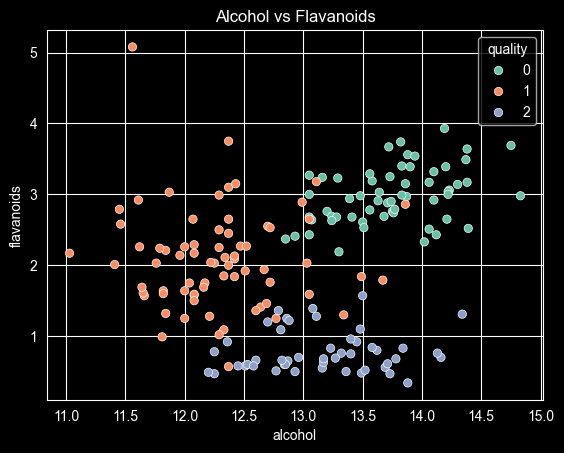

In [72]:
# TODO 19: x="alcohol", y="flavanoids", hue="quality"로 산점도를 확인해봅시다.

sns.scatterplot(data=wine_dataframe, x="alcohol", y="flavanoids", hue="quality", palette="Set2")
plt.title("Alcohol vs Flavanoids")
plt.show()

선택된 특성: ['flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols', 'proline', 'hue']


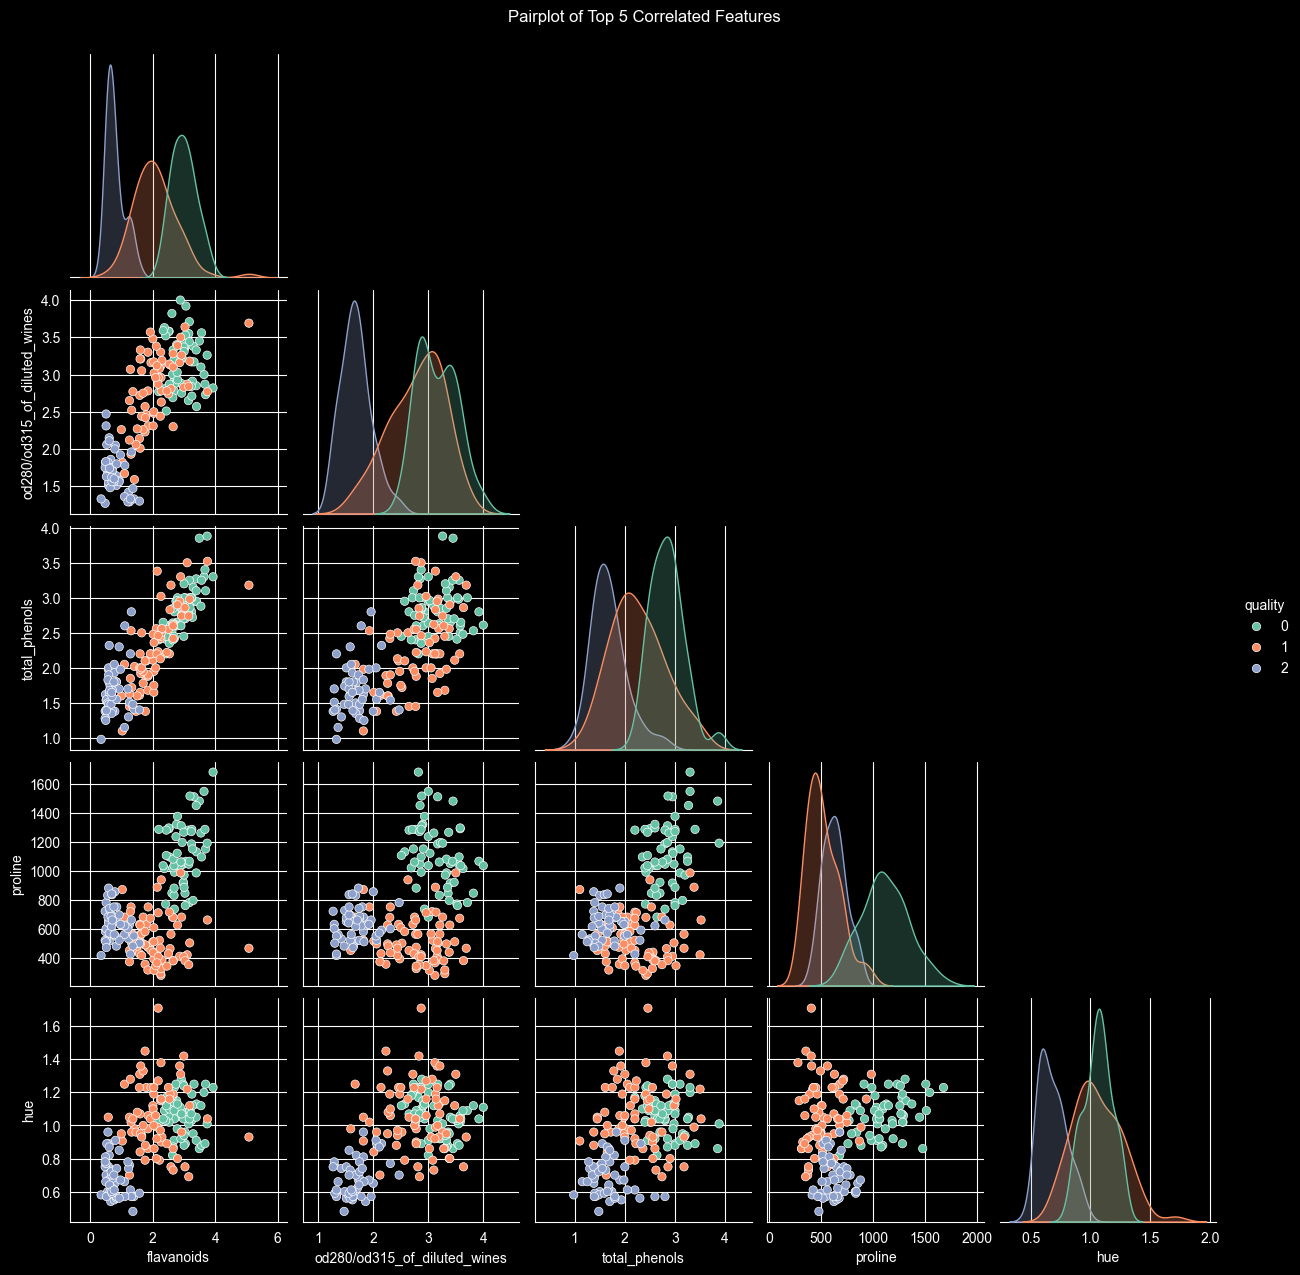

In [73]:
# TODO 20: quality와 상관관계 상위 5개 특성으로 pairplot을 그려봅시다.

corr_with_quality = wine_dataframe.corr(numeric_only=True)["quality"].abs().sort_values(ascending=False)
top_features = corr_with_quality.index[1:6].tolist()
print("선택된 특성:", top_features)

plot_df = wine_dataframe[top_features + ["quality"]]
sns.pairplot(data=plot_df, hue="quality", corner=True, palette="Set2")
plt.suptitle("Pairplot of Top 5 Correlated Features", y=1.02)
plt.show()